[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leoe21/machine_learning_fundamentals/blob/main/02_unidad/02_06_arboles_decision_ensambles.ipynb)


# 02_06 Arboles de decision y ensambles

Objetivo: comparar en un mismo flujo reproducible cuatro enfoques de modelado alineados con el material de clase:

1. **Arbol de decision (AD)** — particion recursiva del espacio; control de complejidad con pre-poda y `ccp_alpha`.
2. **Random Forest** — bagging de arboles con muestreo de filas y columnas; votacion mayoritaria.
3. **Bagging** — ensamble generico sobre un estimador base (aqui un arbol).
4. **XGBoost** — boosting por gradiente con regularizacion y poda por ganancia (`gamma`).

Dataset: **Breast Cancer** (clasificacion binaria), mismo espiritu que los notebooks previos de la unidad.

Antes de ajustar modelos, **exploramos el dataset**: que representa cada fila, que significa la etiqueta, tamano, balance de clases y un vistazo a las variables numericas.


## 1. Arboles de decision (ideas clave)

- Un arbol **parte el espacio de forma recursiva** con reglas del tipo *si variable <= umbral, ve a la izquierda; si no, a la derecha*.
- En **clasificacion**, cada division suele buscar mayor **pureza** del nodo (criterios tipicos: **Gini** o **entropia**).
- Son modelos **interpretables** pero tienden al **sobreajuste** si el arbol crece sin limite.

**Control de complejidad (pre-poda):** limitar profundidad o tamano de hojas, por ejemplo `max_depth`, `min_samples_leaf`, `max_leaf_nodes`.

**Post-poda (cost complexity):** en `sklearn`, `ccp_alpha` penaliza arboles con muchas ramas; valores mayores suelen **simplificar** el arbol y mejorar generalizacion.

> Los arboles **no requieren estandarizar** variables para funcionar (a diferencia de KNN o regresion logistica con distancia/escala), porque solo usan comparaciones de orden en cada variable.

## 2. Random Forest (ensamble tipo bagging)

- Entrena **muchos arboles** sobre **submuestras bootstrap** de las filas y, en cada division, considera solo un **subconjunto aleatorio de variables** (`max_features`).
- La prediccion en clasificacion es **votacion mayoritaria** entre arboles.
- Suele **bajar la varianza** respecto a un solo arbol profundo, manteniendo buen sesgo.

Hiperparametros didacticos:
- `n_estimators`: numero de arboles (mas arboles suelen estabilizar la prediccion).
- `max_features`: cuantas variables ve cada division (clave para **decorrelacion** entre arboles).

## 3. Bagging (Bootstrap Aggregating)

- Idea general: entrenar muchos modelos sobre **muestras bootstrap** y **promediar o votar** predicciones.
- `BaggingClassifier` en `sklearn` encapsula un **estimador base** (aqui un `DecisionTreeClassifier`).
- Parametros utiles: `n_estimators`, `max_samples` (fraccion de filas por arbol), `max_features` (fraccion de columnas por arbol).

## 4. Gradient Boosting y XGBoost

- En boosting, los arboles se agregan **en serie**: cada nuevo arbol intenta corregir errores de los anteriores (en regresion, enfoque en **residuos**; en clasificacion, el objetivo se formula via funcion de perdida y gradiente).
- Hiperparametros sensibles:
  - `learning_rate` (eta): paso de aprendizaje; valores bajos suelen necesitar **mas arboles** pero a veces generalizan mejor.
  - `subsample`: filas usadas por arbol; introduce aleatoriedad y ayuda contra sobreajuste.

**XGBoost** incorpora regularizacion en hojas (`reg_lambda`, `reg_alpha`) y **poda por ganancia** con `gamma`: un split solo se acepta si la mejora supera ese umbral.

> En Colab o entornos nuevos puede ser necesario: `pip install xgboost`

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

try:
    from xgboost import XGBClassifier

    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost no instalado. Instala con: pip install xgboost")
    print("Se usara GradientBoostingClassifier de sklearn como alternativa didactica.")
    from sklearn.ensemble import GradientBoostingClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 5. Dataset: Breast Cancer Wisconsin (conocer los datos)

Usamos el conjunto **Breast Cancer Wisconsin (diagnostic)** incluido en `sklearn`: **569 biopsias** descritas por **30 medidas numericas** derivadas de imagenes de celulas (radio, textura, concavidad, etc.). La tarea es **clasificacion binaria**:

- **`target = 0`**: **maligno** (`malignant`)
- **`target = 1`**: **benigno** (`benign`)

En `sklearn`, la **clase positiva** por defecto en metricas como `precision_score` es la etiqueta **1** (benign). Conviene tenerlo presente al interpretar precision/recall. Revisamos tamano, distribucion de la etiqueta y estadisticos basicos **antes** del `train_test_split`.


In [ ]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
feature_names = list(data.feature_names)

print("Dimensiones:", df.shape[0], "filas x", len(feature_names), "features (+ target en el DataFrame)")
print("Nombres de clase:", dict(enumerate(data.target_names)))
print()
print("Conteo por etiqueta:")
vc = df["target"].value_counts().sort_index()
vc.index = ["malignant (0)", "benign (1)"]
print(vc)
print("Proporcion benign (1):", round(df["target"].mean(), 3))

print("\nPrimeras filas (5 variables + target):")
display(df[feature_names[:5] + ["target"]].head())

print("Resumen numerico de las 30 features:")
display(df[feature_names].describe().T.round(3))

na_total = int(df[feature_names].isna().sum().sum())
print("Valores faltantes en features:", na_total)

print("\n--- Contexto (extracto de la descripcion incluida en sklearn) ---")
descr_lines = data.DESCR.strip().split("\n")
print("\n".join(descr_lines[:22]))


**Comentario:** Hay **mas benignos que malignos**, pero el desbalance es moderado; por eso usamos particion **estratificada** y conviene mirar metricas por clase, no solo accuracy. Las variables son numericas continuas; en este conjunto **no hay NaN** en las features. Los arboles no exigen estandarizacion porque solo usan cortes por umbral en cada variable.


## 6. Particion train/test


In [ ]:
X = df[feature_names]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Forma train:", X_train.shape, "| test:", X_test.shape)
print("Proporcion clase 1 (benign) en train:", round(y_train.mean(), 3))
print("Proporcion clase 1 (benign) en test:", round(y_test.mean(), 3))


**Comentario:** Con `stratify=y`, la proporcion benigno/maligno en train y test **se alinea** con la del dataset completo (seccion 5). Asi el conjunto de prueba no queda sesgado hacia una clase y las metricas entre modelos son comparables.


## 7. Funcion auxiliar: entrenar con CV y evaluar en test

Todos los modelos se calibran con **GridSearchCV** solo sobre **train**; el **test** queda reservado para una lectura final comparable.


In [10]:
def fit_evaluate(name, estimator, param_grid, cv=5):
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    best = grid.best_estimator_

    ytr_hat = best.predict(X_train)
    yte_hat = best.predict(X_test)
    yte_proba = best.predict_proba(X_test)[:, 1]

    row = {
        "modelo": name,
        "best_params": grid.best_params_,
        "cv_ROC_AUC": grid.best_score_,
        "train_accuracy": accuracy_score(y_train, ytr_hat),
        "test_accuracy": accuracy_score(y_test, yte_hat),
        "test_precision": precision_score(y_test, yte_hat),
        "test_recall": recall_score(y_test, yte_hat),
        "test_f1": f1_score(y_test, yte_hat),
        "test_roc_auc": roc_auc_score(y_test, yte_proba),
        "estimator": best,
    }
    return row


results_rows = []

## 8. Modelo 1 — Arbol de decision

Buscamos equilibrio entre ajuste y generalizacion combinando **pre-poda** (`max_depth`, `min_samples_leaf`) y **post-poda** (`ccp_alpha`).


In [11]:
dt_params = {
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 5, 15],
    "ccp_alpha": [0.0, 0.005, 0.02],
}

row_dt = fit_evaluate(
    "DecisionTree",
    DecisionTreeClassifier(random_state=RANDOM_STATE, criterion="gini"),
    dt_params,
)
results_rows.append(row_dt)

print("Mejores hiperparametros:", row_dt["best_params"])
print("CV ROC-AUC:", round(row_dt["cv_ROC_AUC"], 4))
print("Test ROC-AUC:", round(row_dt["test_roc_auc"], 4))

Mejores hiperparametros: {'ccp_alpha': 0.0, 'max_depth': 5, 'min_samples_leaf': 15}
CV ROC-AUC: 0.9676
Test ROC-AUC: 0.9774


**Comentario:** Un `ccp_alpha` distinto de cero actua como **poda por complejidad**: penaliza ramas poco utiles. Si el arbol elegido tiene `ccp_alpha=0`, el modelo confio mas en `max_depth` y `min_samples_leaf` para regularizar.

### Visualizacion parcial del arbol (profundidad limitada)

Solo mostramos los primeros niveles para lectura en clase; el arbol completo puede ser muy grande.

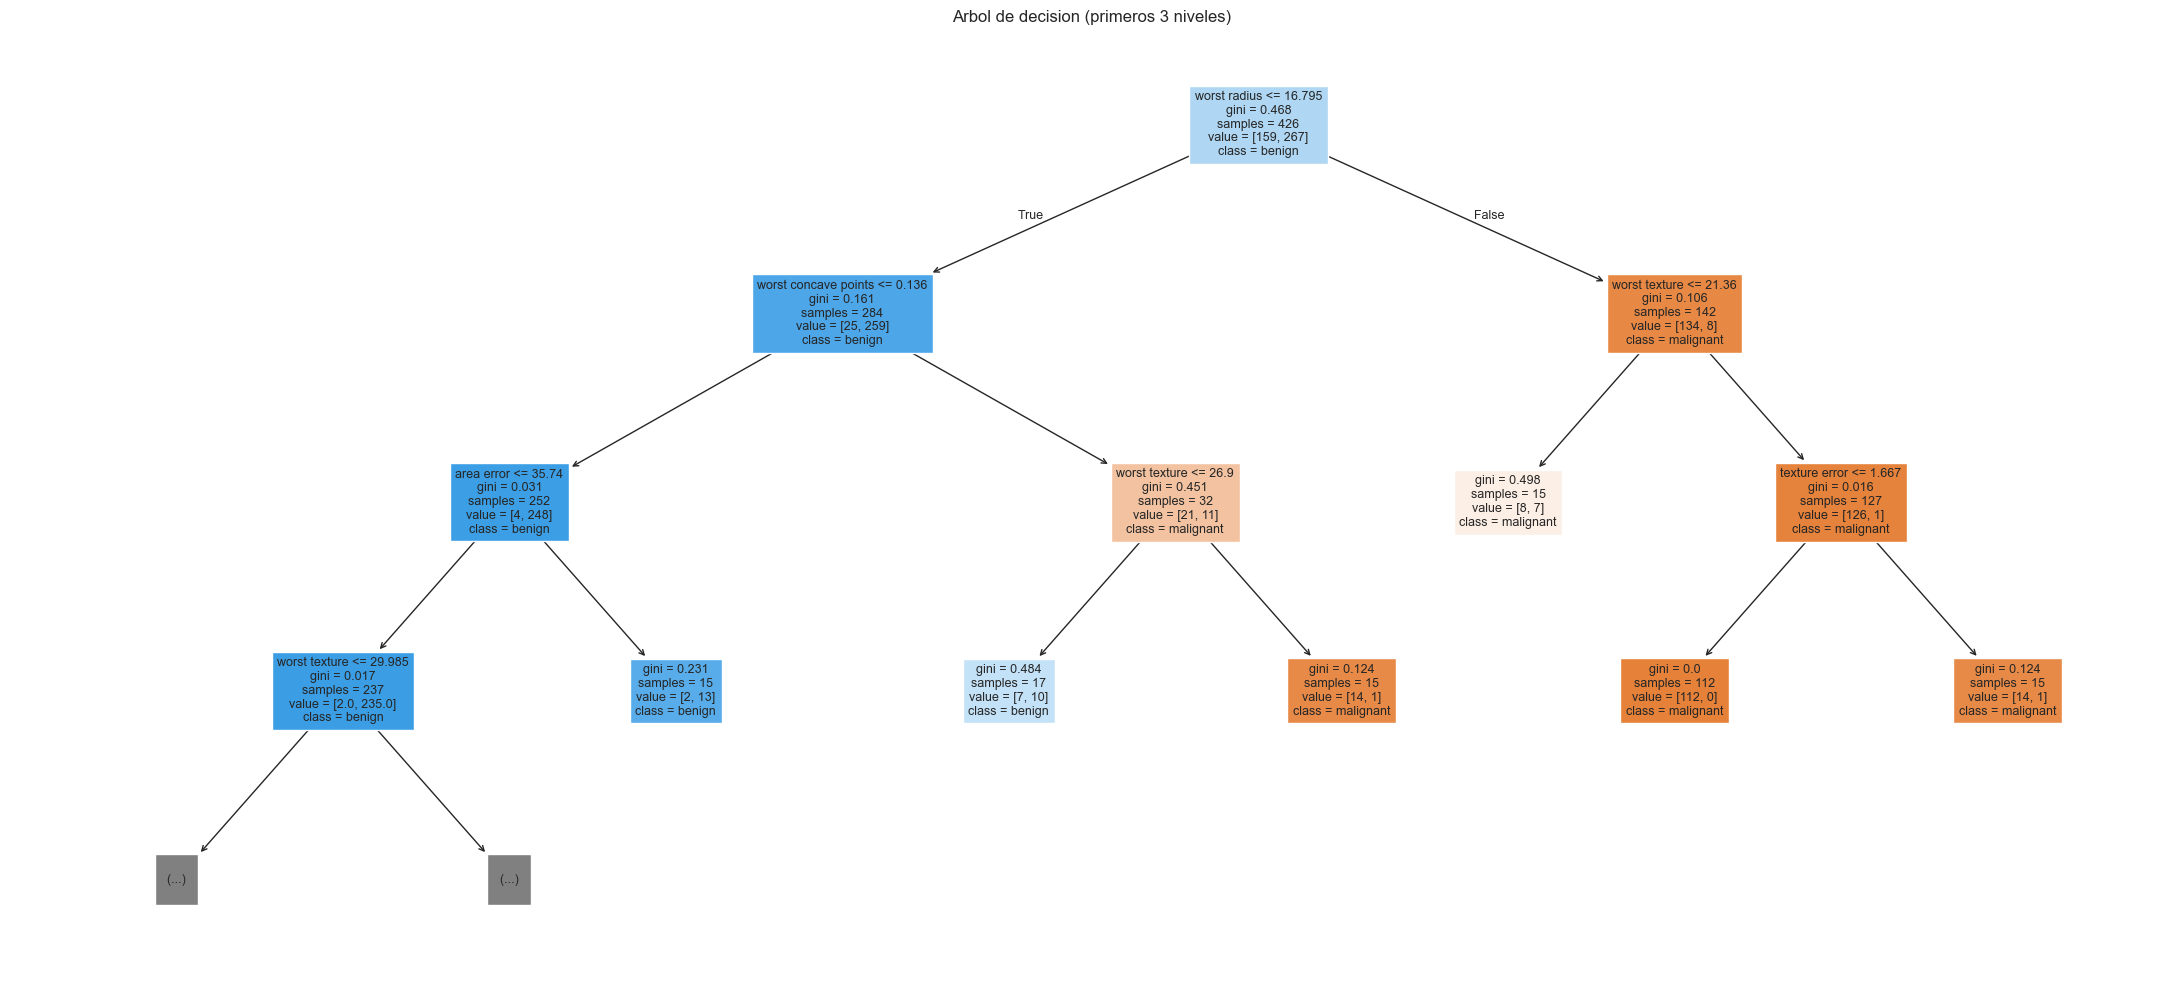

In [19]:
best_dt = row_dt["estimator"]

plt.figure(figsize=(22, 10))
plot_tree(
    best_dt,
    feature_names=feature_names,
    class_names=["malignant", "benign"],
    max_depth=3,
    filled=True,
    fontsize=9,
)
plt.title("Arbol de decision (primeros 3 niveles)")
plt.tight_layout()
plt.show()

**Comentario:** Cada nodo muestra la regla de particion y la distribucion de clases en ese subconjunto. Las variables que aparecen arriba suelen ser las mas discriminativas en este arbol concreto (no implican causalidad).

## 9. Modelo 2 — Random Forest

Calibramos `n_estimators` y `max_features`, alineado con la idea de **decorrelacion** entre arboles.


In [20]:
rf_params = {
    "n_estimators": [100, 200],
    "max_features": ["sqrt", "log2", 0.3],
    "max_depth": [None, 8, 15],
    "min_samples_leaf": [1, 4],
}

row_rf = fit_evaluate(
    "RandomForest",
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params,
)
results_rows.append(row_rf)

print("Mejores hiperparametros:", row_rf["best_params"])
print("CV ROC-AUC:", round(row_rf["cv_ROC_AUC"], 4))
print("Test ROC-AUC:", round(row_rf["test_roc_auc"], 4))

Mejores hiperparametros: {'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 100}
CV ROC-AUC: 0.9927
Test ROC-AUC: 0.9939


**Comentario:** Random Forest promedia el voto de muchos arboles entrenados con distinta submuestra; suele reducir varianza frente a un solo arbol. `max_features` bajo fuerza a los arboles a ver distintos subconjuntos de variables y mezcla mejor los errores.

## 10. Modelo 3 — Bagging sobre arbol de decision

`BaggingClassifier` aplica bootstrap sobre filas (y opcionalmente subconjunto de columnas). Es util para ver el patron **votacion de base debil** sin la logica especifica de Random Forest.


In [14]:
base_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

bag_params = {
    "n_estimators": [50, 100],
    "max_samples": [0.7, 1.0],
    "max_features": [0.5, 1.0],
    "estimator__max_depth": [None, 6, 12],
    "estimator__min_samples_leaf": [1, 5],
}

row_bag = fit_evaluate(
    "Bagging",
    BaggingClassifier(estimator=base_tree, random_state=RANDOM_STATE, n_jobs=-1),
    bag_params,
)
results_rows.append(row_bag)

print("Mejores hiperparametros:", row_bag["best_params"])
print("CV ROC-AUC:", round(row_bag["cv_ROC_AUC"], 4))
print("Test ROC-AUC:", round(row_bag["test_roc_auc"], 4))

Mejores hiperparametros: {'estimator__max_depth': None, 'estimator__min_samples_leaf': 5, 'max_features': 0.5, 'max_samples': 0.7, 'n_estimators': 50}
CV ROC-AUC: 0.9904
Test ROC-AUC: 0.9927


**Comentario:** `max_samples` y `max_features` controlan cuanta diversidad hay entre arboles del ensamble. Si el arbol base es muy profundo, bagging puede volverse costoso; limitar `estimator__max_depth` estabiliza el conjunto.

## 11. Modelo 4 — XGBoost (o alternativa sklearn)

Si `xgboost` no esta instalado, usamos `GradientBoostingClassifier` como sustituto conceptual de boosting por gradiente (misma familia de ideas que en las diapositivas).


In [15]:
if HAS_XGB:
    xgb_params = {
        "n_estimators": [200, 400],
        "max_depth": [3, 6],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
        "reg_lambda": [1, 5],
        "reg_alpha": [0.0, 0.5],
        "gamma": [0.0, 1.0],
    }
    row_xgb = fit_evaluate(
        "XGBoost",
        XGBClassifier(
            random_state=RANDOM_STATE,
            tree_method="hist",
            eval_metric="logloss",
            n_jobs=-1,
        ),
        xgb_params,
    )
else:
    gb_params = {
        "n_estimators": [150, 300],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
    }
    row_xgb = fit_evaluate(
        "GradientBoosting(sklearn)",
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        gb_params,
    )

results_rows.append(row_xgb)

print("Mejores hiperparametros:", row_xgb["best_params"])
print("CV ROC-AUC:", round(row_xgb["cv_ROC_AUC"], 4))
print("Test ROC-AUC:", round(row_xgb["test_roc_auc"], 4))

Mejores hiperparametros: {'gamma': 0.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.0, 'reg_lambda': 5, 'subsample': 1.0}
CV ROC-AUC: 0.9893
Test ROC-AUC: 0.9925


**Comentario:** En XGBoost, `gamma` frena splits poco rentables; `reg_lambda` y `reg_alpha` regularizan la magnitud en hojas (estilo Ridge/Lasso). `learning_rate` y `n_estimators` interactuan: con tasa baja suelen hacer falta mas arboles para el mismo ajuste.

## 12. Comparacion de modelos (test)


,modelo,cv_ROC_AUC,train_accuracy,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,RandomForest,0.992711,1.000000,0.958042,0.956522,0.977778,0.967033,0.993920
1,Bagging,0.990374,0.981221,0.958042,0.956522,0.977778,0.967033,0.992662
2,XGBoost,0.989304,0.997653,0.958042,0.956522,0.977778,0.967033,0.992453
3,DecisionTree,0.967576,0.953052,0.958042,0.966667,0.966667,0.966667,0.977358


Mejor modelo por ROC-AUC en test: RandomForest


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16328\2601753935.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x="test_roc_auc", y="modelo", ax=ax, palette="viridis")


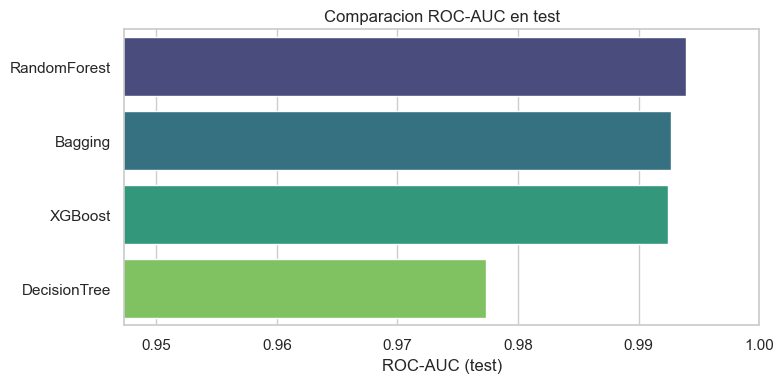

Hiperparametros elegidos por CV:


,modelo,best_params
0,DecisionTree,"{'ccp_alpha': 0.0, 'max_depth': 5, 'min_sample..."
1,RandomForest,"{'max_depth': 8, 'max_features': 'log2', 'min_..."
2,Bagging,"{'estimator__max_depth': None, 'estimator__min..."
3,XGBoost,"{'gamma': 0.0, 'learning_rate': 0.05, 'max_dep..."


In [16]:
summary = (
    pd.DataFrame(results_rows)
    .drop(columns=["estimator", "best_params"])
    .sort_values("test_roc_auc", ascending=False)
    .reset_index(drop=True)
)

display(summary)

best_name = summary.loc[0, "modelo"]
print("Mejor modelo por ROC-AUC en test:", best_name)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=summary, x="test_roc_auc", y="modelo", ax=ax, palette="viridis")
ax.set_xlabel("ROC-AUC (test)")
ax.set_ylabel("")
xmin = max(0.5, float(summary["test_roc_auc"].min()) - 0.03)
ax.set_xlim(xmin, 1.0)
plt.title("Comparacion ROC-AUC en test")
plt.tight_layout()
plt.show()

params_df = pd.DataFrame(
    [{"modelo": r["modelo"], "best_params": str(r["best_params"])} for r in results_rows]
)
print("Hiperparametros elegidos por CV:")
display(params_df)

**Comentario:** La tabla ordena modelos por desempeno en test. Diferencias pequenas pueden deberse a varianza de la muestra; por eso siempre se contrasta con CV y, si hiciera falta, validacion externa.

## 13. Curvas ROC en test (todos los modelos)


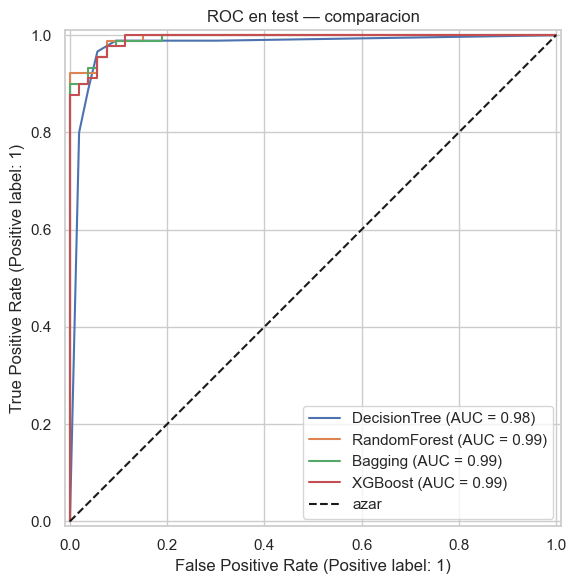

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
for r in results_rows:
    RocCurveDisplay.from_estimator(r["estimator"], X_test, y_test, ax=ax, name=r["modelo"])
ax.plot([0, 1], [0, 1], "k--", label="azar")
ax.set_title("ROC en test — comparacion")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Comentario:** Las curvas ROC resumen la capacidad de ranking del modelo. En ensambles suele observarse una mejora suave respecto al arbol unico, aunque el salto depende del dataset y del tuning.

## 14. Matriz de confusion del mejor modelo (test)


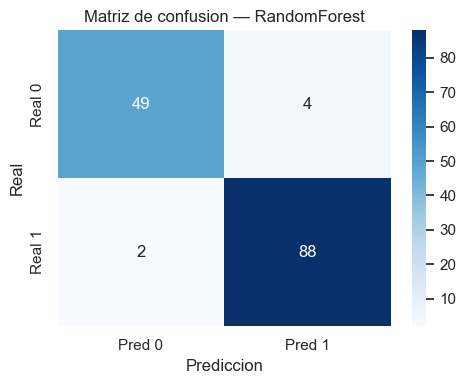

              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



In [18]:
best_row = max(results_rows, key=lambda r: r["test_roc_auc"])
best_model = best_row["estimator"]
y_hat = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_hat)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Real 0", "Real 1"],
)
plt.title(f"Matriz de confusion — {best_row['modelo']}")
plt.xlabel("Prediccion")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_hat, target_names=["malignant", "benign"]))

## 15. Cierre

- **AD:** interpretable; regularizar con profundidad/hojas y `ccp_alpha`.
- **Random Forest:** bagging + aleatoriedad de variables; fuerte en varianza.
- **Bagging:** patron general de votacion sobre un base learner.
- **XGBoost / boosting:** arboles en serie con `learning_rate`, `subsample` y regularizacion (`gamma`, `reg_lambda`, `reg_alpha`).
